# March 21 Model

Applying the following recommendations for improved model performance after first meeting with Javi:
- Drop those around above 75% age
- Threshold only positives, no absolute value so no negatives
- Don’t normalize age
- MSE for optimization, MAE for more predictions/interpretability
- Incorporate early stopping
- Threshold 0.2
- Drop out (0.2 rate)

In [41]:
# Importing libraries

import numpy as np
import pandas as pd

# Load connectivity matrices and phenotypic data
conn = np.load('../../data/conn_clean.npy')
df = pd.read_csv('../../data/pheno_data_clean.csv')

# Confirm shapes and age range
print(f'Connectivity shape: {conn.shape}')
print(f'Pheno data shape: {df.shape}')
print(f'Age range: {df.AGE_AT_SCAN.min():.1f} - {df.AGE_AT_SCAN.max():.1f} years')

Connectivity shape: (458, 200, 200)
Pheno data shape: (458, 104)
Age range: 6.5 - 56.2 years


In [42]:
df['AGE_AT_SCAN'].describe()

count    458.000000
mean      16.732898
std        7.226745
min        6.470000
25%       11.960000
50%       14.725000
75%       19.789775
max       56.200000
Name: AGE_AT_SCAN, dtype: float64

## Limiting age to those below the 75th percentile

In [43]:
# Calculate 75th percentile of age
age_75th = df['AGE_AT_SCAN'].quantile(0.75)
print(f'75th percentile of age: {age_75th:.1f} years')
print(f'Subjects before filtering: {len(df)}')

# Filter out subjects older than 75th percentile

age_mask = df['AGE_AT_SCAN'] <= age_75th
df_filtered = df[age_mask].reset_index(drop = True)
conn_filtered = conn[age_mask]

print(f'Subjects after filtering: {len(df_filtered)}')
print(f'Subjects removed: {len(df) - len(df_filtered)}')
print(f'Age range after filtering: {df_filtered.AGE_AT_SCAN.min():.1f} - {df_filtered.AGE_AT_SCAN.max():.1f} years')
print(f'Age mean: {df_filtered.AGE_AT_SCAN.mean():.1f}, std: {df_filtered.AGE_AT_SCAN.std():.1f}')


75th percentile of age: 19.8 years
Subjects before filtering: 458
Subjects after filtering: 343
Subjects removed: 115
Age range after filtering: 6.5 - 19.8 years
Age mean: 13.3, std: 3.0


## Threshold at 0.2 and only positives, no absolute value

In [44]:
# Positive-only thresholding analysis at threshold 0.2

threshold = 0.2

# Analyze edge counts with positive-only thresholding
edges_per_subject = []

for i in range(conn_filtered.shape[0]):
    matrix = conn_filtered[i]
    upper_tri = np.triu(matrix, k=1)
    positive_edges = np.sum(upper_tri > threshold)
    edges_per_subject.append(positive_edges)

edges_per_subject = np.array(edges_per_subject)

print(f'Threshold: {threshold} (positive only)')
print(f'Mean edges per subject: {edges_per_subject.mean():.0f}')
print(f'Std edges per subject: {edges_per_subject.std():.0f}')
print(f'Min edges per subject: {edges_per_subject.min():.0f}')
print(f'Max edges per subject: {edges_per_subject.max():.0f}')

# Compare to previous absolute value approach
edges_abs = []
for i in range(conn_filtered.shape[0]):
    matrix = conn_filtered[i]
    upper_tri = np.triu(matrix, k=1)
    abs_edges = np.sum(np.abs(upper_tri) > threshold)
    edges_abs.append(abs_edges)

edges_abs = np.array(edges_abs)
print(f'\nComparison with absolute value threshold 0.2:')
print(f'Mean edges per subject: {edges_abs.mean():.0f}')
print(f'\nEdge reduction from dropping negatives: {edges_abs.mean() - edges_per_subject.mean():.0f} edges on average')

# Distribution of correlation values — fixed extraction
rows, cols = np.triu_indices(200, k=1)
all_corrs = np.concatenate([conn_filtered[i][rows, cols] for i in range(conn_filtered.shape[0])])




Threshold: 0.2 (positive only)
Mean edges per subject: 11151
Std edges per subject: 3406
Min edges per subject: 4658
Max edges per subject: 19270

Comparison with absolute value threshold 0.2:
Mean edges per subject: 11421

Edge reduction from dropping negatives: 270 edges on average


### New graph construction

In [45]:
import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split

def matrix_to_graph(matrix, age, threshold=0.2):
    """Converting a single subject's connectivity matrix into a PyG graph object."""
    
    num_nodes = matrix.shape[0]
    
    # Node features: each node's row from the matrix (its connectivity profile)
    node_features = torch.tensor(matrix, dtype=torch.float)
    
    # Getting upper triangle indices (excluding diagonal)
    row, col = np.triu_indices(num_nodes, k=1)
    
    # Getting the correlation values for those pairs
    weights = matrix[row, col]
    
    # Positive-only: only keep edges where correlation is above threshold (no abs)
    mask = weights > threshold
    row = row[mask]
    col = col[mask]
    weights = weights[mask]
    
    # Make edges bidirectional
    edge_index = torch.tensor(np.array([
        np.concatenate([row, col]),
        np.concatenate([col, row])
    ]), dtype=torch.long)
    
    # Edge weights
    edge_attr = torch.tensor(
        np.concatenate([weights, weights]), dtype=torch.float
    ).unsqueeze(1)
    
    # Target age
    y = torch.tensor([age], dtype=torch.float)
    
    return Data(x=node_features, edge_index=edge_index, edge_attr=edge_attr, y=y)


In [46]:
# Build dataset at threshold 0.2 with filtered subjects
ages = df_filtered['AGE_AT_SCAN'].values
graphs = [matrix_to_graph(conn_filtered[i], ages[i], threshold=0.2) for i in range(len(ages))]

print(f'Total graphs: {len(graphs)}')
print(f'Sample graph edges: {graphs[0].edge_index.shape[1]}, node features: {graphs[0].x.shape}, age: {graphs[0].y.item():.1f}')

# Split indices
indices = list(range(len(ages)))
train_idx, temp_idx = train_test_split(indices, test_size=0.3, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=42)

print(f'Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}')

Total graphs: 343
Sample graph edges: 26810, node features: torch.Size([200, 200]), age: 12.9
Train: 240 | Val: 51 | Test: 52


In [47]:
# Apply split
train_graphs = [graphs[i] for i in train_idx]
val_graphs = [graphs[i] for i in val_idx]
test_graphs = [graphs[i] for i in test_idx]

# DataLoaders
train_loader = DataLoader(train_graphs, batch_size=8, shuffle=True)
val_loader = DataLoader(val_graphs, batch_size=8, shuffle=False)
test_loader = DataLoader(test_graphs, batch_size=8, shuffle=False)

print(f'DataLoaders created')
print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}')

DataLoaders created
Train batches: 30 | Val batches: 7 | Test batches: 7


## Modeling

New additions:
- Early stopping
- Dropout rate (0.2)
- MAE

In [48]:
import copy
import torch
import torch.nn as nn
from torch_geometric.nn import GCNConv, global_mean_pool, BatchNorm

class BrainAgeGNN(nn.Module):
    def __init__(self, num_node_features, hidden_dim=64):
        super().__init__()
        
        # 2 graph convolution layers with batch normalization
        self.conv1 = GCNConv(num_node_features, hidden_dim)
        self.bn1 = BatchNorm(hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.bn2 = BatchNorm(hidden_dim)

        self.dropout = nn.Dropout(p=0.2) # Adding dropout layer for regularization
        
        # Output layer — maps pooled graph embedding to single age prediction
        self.fc = nn.Linear(hidden_dim, 1)
        self.relu = nn.ReLU()
    
    def forward(self, data):
        # Clone inputs to prevent in-place corruption of original data
        x = data.x.clone()
        edge_index = data.edge_index.clone()
        batch = data.batch
        
        # Graph convolution layers
        x = self.relu(self.bn1(self.conv1(x, edge_index)))
        x = self.dropout(x)
        x = self.relu(self.bn2(self.conv2(x, edge_index)))
        x = self.dropout(x)
        
        # Pool all node embeddings into one graph-level vector
        x = global_mean_pool(x, batch)
        x = self.dropout(x)
        x = self.fc(x)
        
        return x.squeeze()

In [49]:
def train_one_epoch(model, loader):
    model.train()
    total_mse = 0
    total_mae = 0
    for batch in loader:
        optimizer.zero_grad()
        pred = model(batch)
        loss = loss_fn(pred, batch.y)
        loss.backward()
        # Clip gradients to prevent exploding values
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_mse += loss.item() * batch.num_graphs
        total_mae += torch.mean(torch.abs(pred - batch.y)).item() * batch.num_graphs
    return total_mse / len(loader.dataset), total_mae / len(loader.dataset)

def evaluate(model, loader):
    model.eval()
    total_mse = 0
    total_mae = 0
    with torch.no_grad():
        for batch in loader:
            pred = model(batch)
            mse = loss_fn(pred, batch.y)
            mae = torch.mean(torch.abs(pred - batch.y))
            total_mse += mse.item() * batch.num_graphs
            total_mae += mae.item() * batch.num_graphs
    return total_mse / len(loader.dataset), total_mae / len(loader.dataset)

In [50]:
model = BrainAgeGNN(num_node_features=200)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

# Training with early stopping
num_epochs = 200
patience = 20
patience_counter = 0
best_val_loss = float('inf')
best_model_weights = None

train_losses = []
train_maes = []
val_losses = []
val_maes = []

for epoch in range(1, num_epochs + 1):
    train_mse, train_mae = train_one_epoch(model, train_loader)  # unpack both
    val_mse, val_mae = evaluate(model, val_loader)
    
    train_losses.append(train_mse)
    train_maes.append(train_mae)
    val_losses.append(val_mse)
    val_maes.append(val_mae)
    
    # Early stopping check
    if val_mse < best_val_loss:
        best_val_loss = val_mse
        best_val_mae = val_mae
        best_train_mae = train_mae
        patience_counter = 0
        best_model_weights = copy.deepcopy(model.state_dict())
    else:
        patience_counter += 1
    
    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d} | Train MSE: {train_mse:.4f} | Train MAE: {train_mae:.4f} yrs | Val MSE: {val_mse:.4f} | Val MAE: {val_mae:.4f} yrs | Patience: {patience_counter}/{patience}')
    
    if patience_counter >= patience:
        print(f'\nEarly stopping triggered at epoch {epoch}')
        break

# Restore best weights
model.load_state_dict(best_model_weights)
print(f'\nBest model restored — Train MAE: {best_train_mae:.4f} yrs | Val MSE: {best_val_loss:.4f} | Val MAE: {best_val_mae:.4f} yrs')

Epoch  10 | Train MSE: 9.8854 | Train MAE: 2.5727 yrs | Val MSE: 60.0247 | Val MAE: 6.0134 yrs | Patience: 1/20
Epoch  20 | Train MSE: 4.4709 | Train MAE: 1.6461 yrs | Val MSE: 16.7780 | Val MAE: 3.4092 yrs | Patience: 5/20
Epoch  30 | Train MSE: 3.3389 | Train MAE: 1.4305 yrs | Val MSE: 12.9764 | Val MAE: 2.9544 yrs | Patience: 15/20

Early stopping triggered at epoch 35

Best model restored — Train MAE: 1.7621 yrs | Val MSE: 10.7888 | Val MAE: 2.7390 yrs


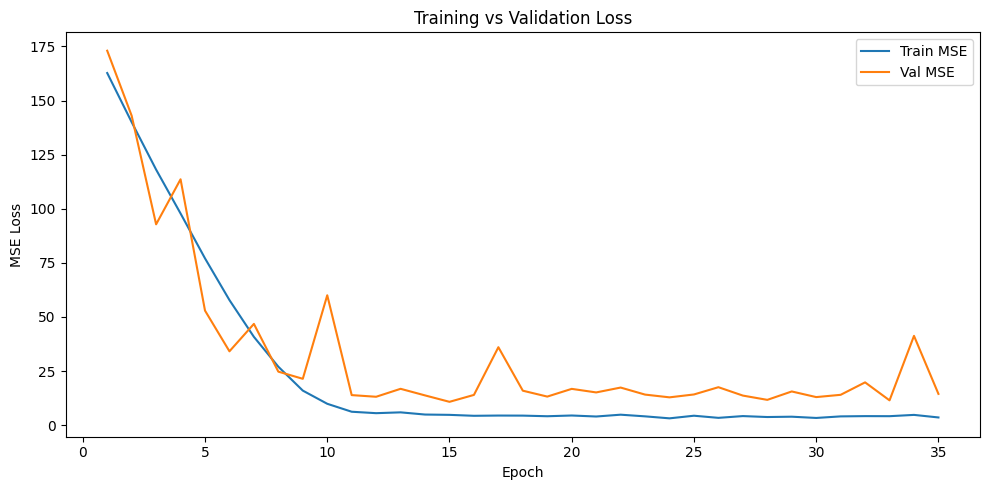

In [51]:
import matplotlib.pyplot as plt

epochs_ran = len(train_losses)

plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs_ran + 1), train_losses, label='Train MSE')
plt.plot(range(1, epochs_ran + 1), val_losses, label='Val MSE')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()